# Has the Paris Agreement Changed Global CO2 Emissions?

The Paris Agreement, signed in December 2015, saw nearly every country in the world
commit to limiting global warming to well below 2°C. Now, almost a decade later, 
the data is in. This notebook asks a simple question:

**Did anything actually change?**

We'll look at:
1. Where the world stood in 2015
2. Whether global emissions have fallen since
3. Which countries reduced their emissions, and which didn't
4. Whether 2015 was an inflection point or just a continuation of existing trends

**Data source:** [Our World in Data — CO2 and Greenhouse Gas Emissions](https://github.com/owid/co2-data)

In [1]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

# Database connection — relative path so this works on any machine
db_path = Path('..') / 'data' / 'CO2_emissions.db'
conn = sqlite3.connect(db_path)
# Countries we'll focus on throughout the analysis
KEY_COUNTRIES = ['China', 'United States', 'India', 'European Union (27)',
                 'United Kingdom', 'Russia', 'Japan', 'Brazil', 'Italy']

PARIS_YEAR = 2015

# Connect to SQLite database


## 1. Where was the world in 2015?

Before asking what changed, we need to understand the starting point. When the Paris 
Agreement was signed in December 2015, who were the biggest emitters?

In [2]:
query = """
SELECT 
    country,
    CAST(co2 AS REAL) as co2_emissions,
    ROUND(
        CAST(co2 AS REAL) * 100.0 / SUM(CAST(co2 AS REAL)) OVER (),
        2
    ) as pct_of_global
FROM co2
WHERE year = 2015
AND iso_code IS NOT NULL
AND iso_code != ''
AND co2 != ''
ORDER BY co2_emissions DESC
LIMIT 10;
"""

top_2015 = pd.read_sql_query(query, conn)
top_2015

,country,co2_emissions,pct_of_global
0,China,9858.040,28.79
1,United States,5368.497,15.68
2,India,2231.817,6.52
3,Russia,1635.244,4.78
4,Japan,1219.982,3.56
5,Germany,800.823,2.34
6,Iran,641.959,1.87
7,South Korea,634.177,1.85
8,Saudi Arabia,624.547,1.82
9,Canada,563.003,1.64


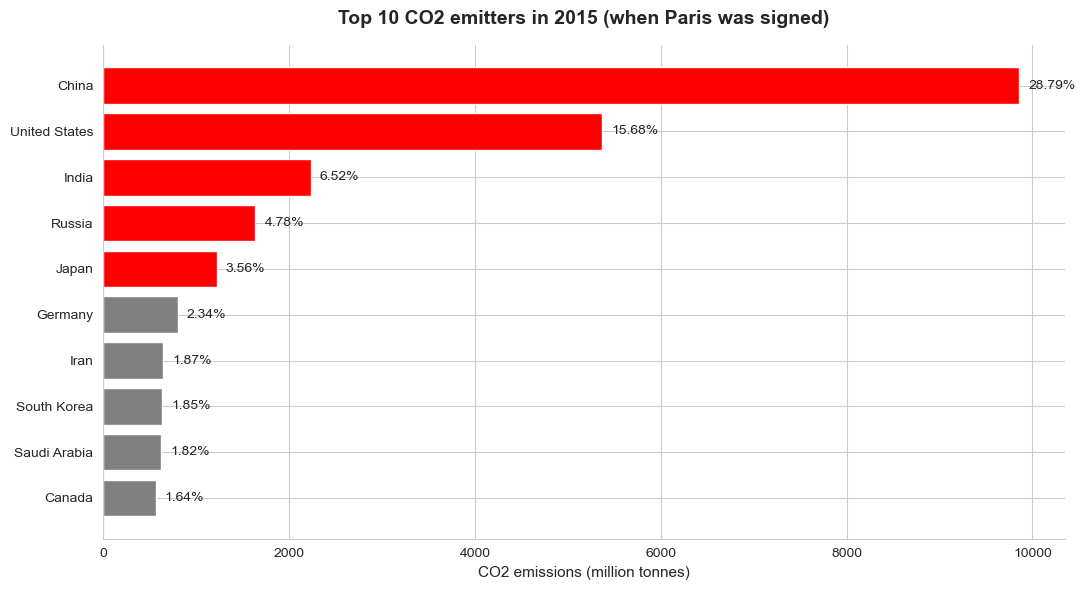

In [3]:
fig, ax = plt.subplots(figsize=(11, 6))

# Horizontal bar chart, sorted with biggest at top
top_2015_sorted = top_2015.sort_values('co2_emissions')

# Highlight our key countries in colour, others in grey
colors = ['red' if c in KEY_COUNTRIES else 'grey' 
          for c in top_2015_sorted['country']]

bars = ax.barh(top_2015_sorted['country'], top_2015_sorted['co2_emissions'], 
               color=colors, edgecolor='white')

# Add percentage labels at the end of each bar
for bar, pct in zip(bars, top_2015_sorted['pct_of_global']):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'{pct}%', va='center', fontsize=10)

ax.set_xlabel('CO2 emissions (million tonnes)', fontsize=11)
ax.set_title('Top 10 CO2 emitters in 2015 (when Paris was signed)', 
             fontsize=14, fontweight='bold', pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

**Key takeaway:** In 2015, just three countries - China, the United States and India - 
accounted for over **half** (51%) of global CO2 emissions. China alone was responsible 
for nearly 29% - more than the US, India and Russia combined. Any meaningful global 
decline must come from these top emitters.

## 2. Has global emissions actually fallen?

If the Paris Agreement worked, we'd expect global emissions to plateau or decline 
after 2015. Let's look at the trend over the past few decades.


In [4]:
query = """
SELECT 
    year,
    SUM(CAST(co2 AS REAL)) as global_co2
FROM co2
WHERE iso_code IS NOT NULL
AND iso_code != ''
AND co2 != ''
AND year BETWEEN 1990 AND 2024
GROUP BY year
ORDER BY year;
"""

global_trend = pd.read_sql_query(query, conn)
global_trend.tail()

,year,global_co2
30,2020,34310.228
31,2021,35978.968
32,2022,36553.536
33,2023,37003.074
34,2024,37398.067


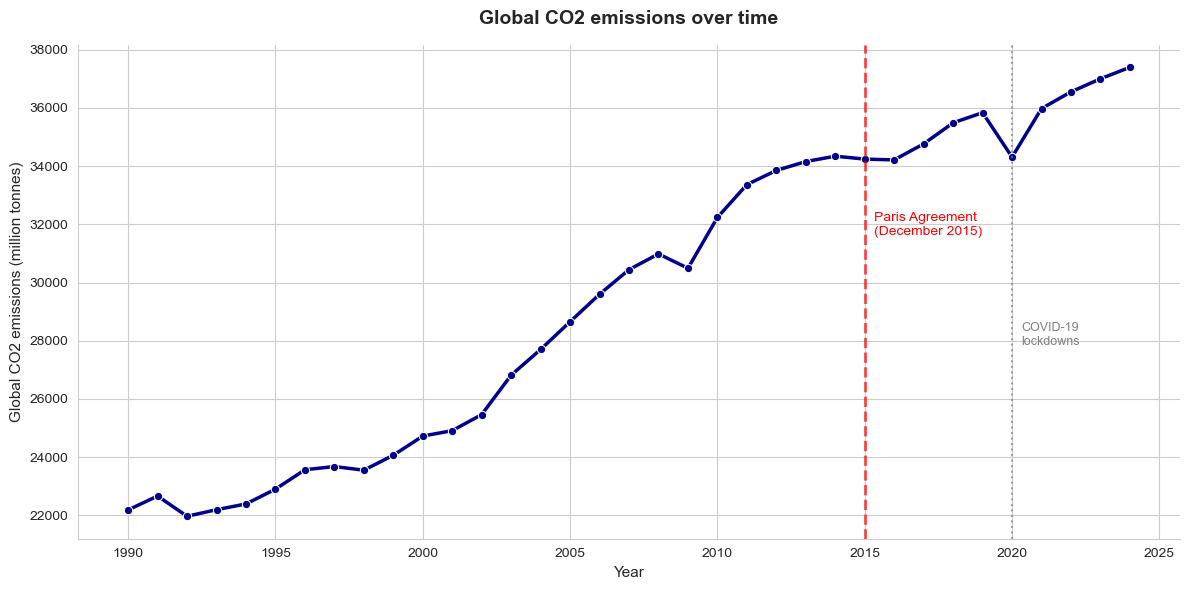

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))

# Main line
sns.lineplot(data=global_trend, x='year', y='global_co2',
             color='darkblue', linewidth=2.5, marker='o', markersize=6, ax=ax)

# Highlight the Paris Agreement year
ax.axvline(x=PARIS_YEAR, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax.text(PARIS_YEAR + 0.3, ax.get_ylim()[1] * 0.85, 
        'Paris Agreement\n(December 2015)', 
        fontsize=10, color='red', verticalalignment='top')

# Highlight the COVID dip
ax.axvline(x=2020, color='grey', linestyle=':', linewidth=1.5, alpha=0.7)
ax.text(2020 + 0.3, ax.get_ylim()[1] * 0.75, 
        'COVID-19\nlockdowns', 
        fontsize=9, color='grey', verticalalignment='top')

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Global CO2 emissions (million tonnes)', fontsize=11)
ax.set_title('Global CO2 emissions over time', fontsize=14, fontweight='bold', pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

**Key takeaway:** Global emissions rose steeply from 1990 to roughly 2013, then their growth slowed noticeably around the Paris Agreement era. However, "growth slowing" is not the same as "emissions falling" - the global total has plateaued at record levels rather than declining. The temporary 2020 dip from COVID lockdowns was quickly reversed. To assess whether this plateau is meaningful, we next compare it to what would have happened if the pre-Paris trend had continued.

### A counterfactual: what if pre-Paris trends had continued?

The global plateau is suggestive, but "the line went sideways" is a weak claim on 
its own - emissions could have flattened for many reasons unrelated to Paris. A 
more informative question is: **how much higher would emissions be today if the 
1990–2014 growth trajectory had simply continued?**

To answer this, we fit a linear regression to the pre-Paris period (1990–2014) 
and extrapolate it forward. This extrapolation acts as a **"business as usual" 
(BAU) baseline** - what we'd expect if the pre-Paris trajectory had simply 
continued. The gap between BAU and actual values is a crude estimate of "how 
much shifted" in the Paris era.

*Caveat: linear extrapolation across decades is fragile - growth processes are 
rarely truly linear over long horizons. This is a back-of-the-envelope 
counterfactual, not a rigorous causal claim.*

In [6]:
from scipy.stats import linregress

# Split into pre-Paris (training) and full timeline (for plotting)
pre_paris = global_trend[global_trend['year'] <= 2014]
full_timeline = global_trend.copy()

# Fit a linear regression on 1990-2014
fit = linregress(pre_paris['year'], pre_paris['global_co2'])

# Generate predictions across the full timeline
full_timeline['counterfactual'] = fit.slope * full_timeline['year'] + fit.intercept

# Compute the gap at the latest year
latest_year = full_timeline['year'].max()
latest_actual = full_timeline.loc[full_timeline['year'] == latest_year, 'global_co2'].values[0]
latest_counterfactual = full_timeline.loc[full_timeline['year'] == latest_year, 'counterfactual'].values[0]
gap = latest_counterfactual - latest_actual
gap_pct = gap / latest_counterfactual * 100

print(f"Linear regression on 1990-2014:")
print(f"  Slope:        {fit.slope:.1f} Mt CO2 per year")
print(f"  Intercept:    {fit.intercept:.0f}")
print(f"  R²:           {fit.rvalue ** 2:.4f}")
print(f"  P-value:      {fit.pvalue:.2e}")
print()
print(f"In {latest_year}:")
print(f"  Actual emissions:        {latest_actual:,.0f} Mt")
print(f"  Counterfactual (BAU):    {latest_counterfactual:,.0f} Mt")
print(f"  Gap:                     {gap:,.0f} Mt ({gap_pct:.1f}% below BAU)")



Linear regression on 1990-2014:
  Slope:        575.3 Mt CO2 per year
  Intercept:    -1124619
  R²:           0.9484
  P-value:      2.66e-16

In 2024:
  Actual emissions:        37,398 Mt
  Counterfactual (BAU):    39,732 Mt
  Gap:                     2,333 Mt (5.9% below BAU)


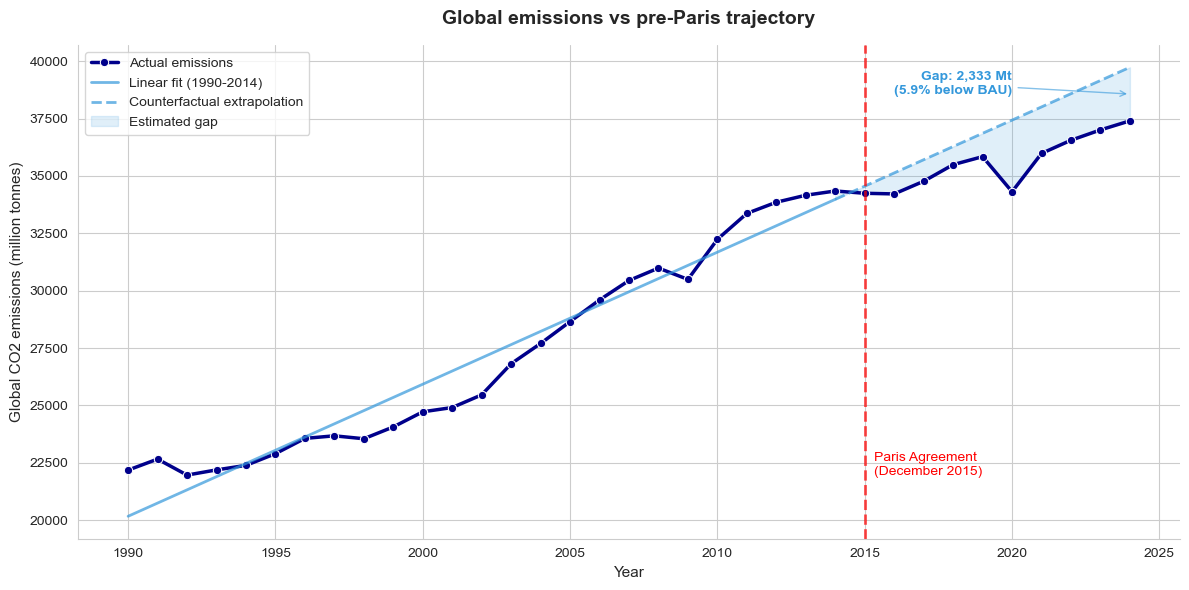

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

# Actual emissions
sns.lineplot(data=full_timeline, x='year', y='global_co2', color='darkblue', linewidth=2.5, marker='o', markersize=6, ax=ax, label='Actual emissions')

# Counterfactual extrapolation (the BAU line)
# Solid for the fitted period, dashed for the extrapolation
fitted_period = full_timeline[full_timeline['year'] <= 2014]
extrapolated = full_timeline[full_timeline['year'] >= 2014]

ax.plot(fitted_period['year'], fitted_period['counterfactual'], color='#3498db', linewidth=2, linestyle='-', alpha=0.7, label='Linear fit (1990-2014)')
ax.plot(extrapolated['year'], extrapolated['counterfactual'], color='#3498db', linewidth=2, linestyle='--', alpha=0.7, label='Counterfactual extrapolation')

# Shade the gap between actual and counterfactual after 2014
post_paris = full_timeline[full_timeline['year'] >= 2014]
ax.fill_between(post_paris['year'], 
                post_paris['global_co2'], 
                post_paris['counterfactual'],
                color='#3498db', alpha=0.15, label='Estimated gap')

# Paris Agreement marker
ax.axvline(x=PARIS_YEAR, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax.text(PARIS_YEAR + 0.3, 23000, 'Paris Agreement\n(December 2015)', fontsize=10, color='red', verticalalignment='top')

# Annotate the gap at the latest year
ax.annotate(f'Gap: {gap:,.0f} Mt\n({gap_pct:.1f}% below BAU)',
            xy=(latest_year, (latest_actual + latest_counterfactual) / 2),
            xytext=(latest_year - 4, (latest_actual + latest_counterfactual) / 2),
            fontsize=10, color='#3498db', fontweight='bold',
            ha='right',
            arrowprops=dict(arrowstyle='->', color='#3498db', alpha=0.6))

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Global CO2 emissions (million tonnes)', fontsize=11)
ax.set_title('Global emissions vs pre-Paris trajectory', fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='upper left', fontsize=10, frameon=True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

**Key takeaway:** Compared to the long-run 1990–2014 trajectory (+575 Mt/year, R² = 0.95), global emissions in 2024 were about **2,300 Mt - roughly 6% - below business-as-usual**. The gap is roughly the size of India's annual emissions.

However, this likely overstates the "Paris effect": growth had already started moderating in the early 2010s for structural reasons unrelated to climate policy (see the sanity check below). A more honest framing is that the world has been slowly bending the long-run emissions curve since the early 2010s, with Paris as one milestone in a longer process - not a sudden inflection point.

Whether this break is *caused by* the Paris Agreement or driven by contemporaneous factors (rapid renewables deployment, China's economic slowdown, structural decline of coal in the OECD) cannot be determined from this data alone.

### Sanity check: is our 1990–2014 baseline reasonable?

A reasonable critique of our counterfactual is that the pre-Paris baseline might already have been slowing - in which case some of the "Paris effect" would just be a continuation of an existing trend. To check this, we fit separate linear regressions over several sub-windows and compare slopes.

In [8]:
# Compare slopes across different time windows to check baseline stability
windows = {
    '1990-2007 (long-run growth)': (1990, 2007),
    '2008-2009 (financial crisis)': (2008, 2009),
    '2010-2014 (post-crisis recovery)': (2010, 2014),
    '2011-2014 (excluding rebound)': (2011, 2014),
    '2015-2019 (post-Paris)': (2015, 2019),
    '2020-2024 (COVID era)': (2020, 2024),
}

print(f"{'Window':<38} {'Slope (Mt/year)':<18} {'R²':<8}")
print("-" * 65)
for label, (start, end) in windows.items():
    subset = global_trend[(global_trend['year'] >= start) & (global_trend['year'] <= end)]
    if len(subset) < 2:
        continue
    f = linregress(subset['year'], subset['global_co2'])
    print(f"{label:<38} {f.slope:>+10.1f}       {f.rvalue**2:.3f}")

Window                                 Slope (Mt/year)    R²      
-----------------------------------------------------------------
1990-2007 (long-run growth)                +474.8       0.887
2008-2009 (financial crisis)               -493.3       1.000
2010-2014 (post-crisis recovery)           +500.3       0.882
2011-2014 (excluding rebound)              +323.6       0.958
2015-2019 (post-Paris)                     +446.7       0.929
2020-2024 (COVID era)                      +720.0       0.892


**Mixed signals.** The pre-Paris growth rate was not constant. Three observations stand out:

1. **The long-run pace was +475 Mt/year** (1990–2007) - driven largely by China's industrialisation
2. **Growth had already moderated to +324 Mt/year by 2011–2014**, well before the Paris Agreement
3. **2015–2019 settled at +447 Mt/year** - a slowdown vs the long-run, but actually faster than the immediate pre-Paris years

The 1990–2014 regression we used averages over these sub-trends. It captures the long-run trajectory accurately, but masks the fact that growth was already slowing in the early 2010s. The 2010–2014 sub-window looks "fast" largely because of the 2009→2010 rebound from the financial crisis - once that bounce-back is excluded (2011–2014), the underlying pre-Paris pace was already slower than the post-Paris pace.

**The honest takeaway:** the 2,300 Mt gap below the long-run trajectory in 2024 is real, but only some of it can be attributed to post-Paris policy choices - much of the deceleration was already underway before 2015. The Paris-era plateau is best understood as part of a longer structural shift, not a sudden break. This makes the country-level analysis in the next section especially important: the global slowdown is the sum of very different national trajectories.

## 3. Country by country: who reduced and who didn't?

The global picture is muddled. Some of the post-2015 plateau reflects genuine policy-driven reductions; some reflects structural shifts that were already underway. To untangle this, we need to look at countries individually.

Let's compare each key country's average annual emissions in the **5 years before** Paris (2010–2014) against the **5 years after** (2018–2022). We use 2018–2022 rather than 2015–2019 to give countries a few years to translate commitments into action and to avoid the immediate transition period.

*Note on window choice: We use 2010–2014 rather than a wider pre-Paris window to avoid the 2008–2009 financial crisis, which temporarily depressed emissions in many countries for reasons unrelated to climate policy.*

In [9]:
query = """
SELECT 
    country,
    ROUND(AVG(CASE WHEN year BETWEEN 2010 AND 2014 THEN CAST(co2 AS REAL) END), 0) as avg_pre_paris,
    ROUND(AVG(CASE WHEN year BETWEEN 2018 AND 2022 THEN CAST(co2 AS REAL) END), 0) as avg_post_paris,
    ROUND(
        (AVG(CASE WHEN year BETWEEN 2018 AND 2022 THEN CAST(co2 AS REAL) END) 
        - AVG(CASE WHEN year BETWEEN 2010 AND 2014 THEN CAST(co2 AS REAL) END))
        * 100.0 / 
        AVG(CASE WHEN year BETWEEN 2010 AND 2014 THEN CAST(co2 AS REAL) END),
        2
    ) as pct_change
FROM co2
WHERE country IN ('China', 'United States', 'India', 'European Union (27)', 'United Kingdom', 'Russia', 'Japan', 'Brazil', 'Italy')
AND co2 != ''
GROUP BY country
ORDER BY pct_change;
"""

paris_change = pd.read_sql_query(query, conn)
paris_change

,country,avg_pre_paris,avg_post_paris,pct_change
0,United Kingdom,477.0,345.0,-27.72
1,Italy,396.0,333.0,-15.87
2,Japan,1269.0,1073.0,-15.45
3,European Union (27),3245.0,2824.0,-12.98
4,United States,5509.0,5073.0,-7.92
5,Brazil,498.0,476.0,-4.41
6,Russia,1659.0,1679.0,1.24
7,China,9563.0,10991.0,14.93
8,India,1903.0,2627.0,38.06


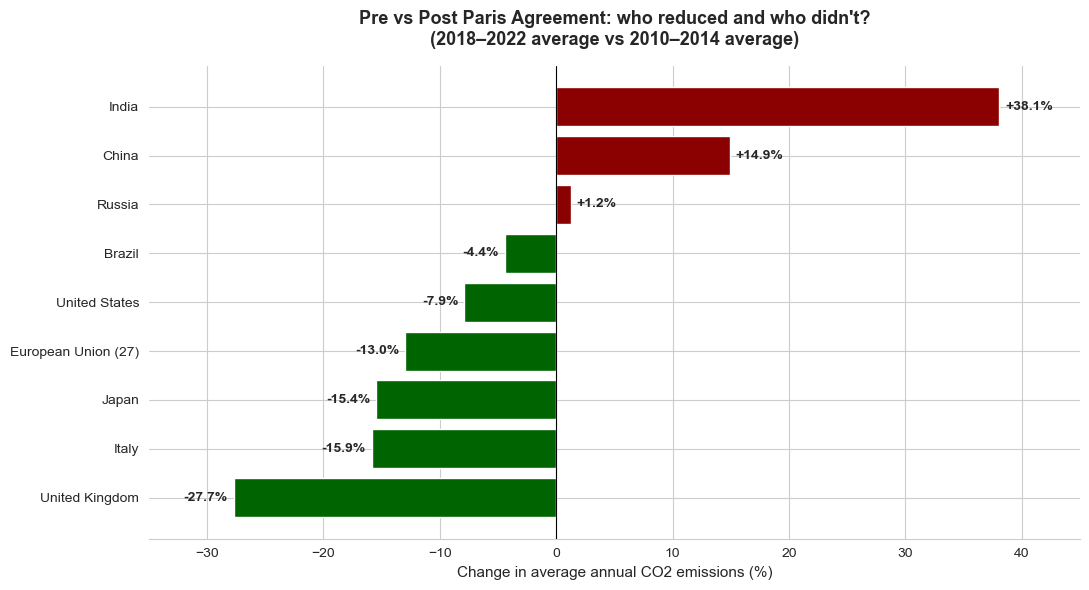

In [10]:
fig, ax = plt.subplots(figsize=(11, 6))

# Green for reductions, red for increases
colors = ['darkgreen' if v < 0 else 'darkred' for v in paris_change['pct_change']]

bars = ax.barh(paris_change['country'], paris_change['pct_change'], color=colors, edgecolor='white')

# Value labels with signed formatting
for bar, val in zip(bars, paris_change['pct_change']):
    offset = 0.5 if val >= 0 else -0.5
    ha = 'left' if val >= 0 else 'right'
    ax.text(bar.get_width() + offset, bar.get_y() + bar.get_height()/2,
            f'{val:+.1f}%', va='center', ha=ha, fontsize=10, fontweight='bold')

# Zero reference line
ax.axvline(x=0, color='black', linewidth=0.8)

ax.set_xlabel('Change in average annual CO2 emissions (%)', fontsize=11)
ax.set_title("Pre vs Post Paris Agreement: who reduced and who didn't?\n(2018–2022 average vs 2010–2014 average)", 
             fontsize=13, fontweight='bold', pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_xlim(-35,45)

plt.tight_layout()
plt.show()

**Key takeaways:**

The global plateau hides three very different stories:

**🟢 The decarbonising bloc.** The UK (-28%), EU-27 (-13%), Italy (-16%) and Japan (-15%) made the biggest cuts. These are mature, post-industrial economies with high baseline emissions, strong policy frameworks, and electricity grids transitioning away from coal. The UK in particular stands out: a 28% reduction in less than a decade is one of the most aggressive national decarbonisations in any G20 country.

**🟡 The slow-movers.** The US (-8%), Brazil (-4%) and Russia (+1%) barely shifted. The US is interesting - much of its coal-to-gas transition (driven by cheap shale gas) happened in the late 2000s, before our pre-Paris baseline window, so the post-2010 gains look modest by comparison.

**🔴 The growth economies.** China (+15%) and India (+38%) drove most of the absolute global increase. Their growth reflects ongoing industrialisation and rising energy demand from large populations - not a failure of climate ambition, but a different development trajectory. India in particular is plausibly the central climate policy question of the 2030s.

**The big picture:** the world's emissions plateau is the net result of rich countries cutting and developing countries growing. Whether this trade-off continues depends entirely on whether China and India can break the historical link between economic development and rising emissions.

### 3.2 Caveat: production vs consumption - is the West just outsourcing?

There is a long-standing critique of headline emissions numbers: they measure **production** (emissions released *within* a country's borders), not 
**consumption** (emissions associated with goods and services a country actually *uses*).

Under production-based accounting, a UK car company that closes its factory and imports identical cars from China shows up as a "reduction" - even though the emissions just migrated abroad. This is called **carbon leakage**, and it's the most common critique of OECD decarbonisation claims.

OWID provides a `consumption_co2` column that adjusts for trade. Let's compare the two for our key countries.

In [11]:
query = """
SELECT 
    country,
    ROUND(AVG(CASE WHEN year BETWEEN 2010 AND 2014 
              THEN CAST(co2 AS REAL) END), 0) as prod_pre,
    ROUND(AVG(CASE WHEN year BETWEEN 2018 AND 2022 
              THEN CAST(co2 AS REAL) END), 0) as prod_post,
    ROUND(
        (AVG(CASE WHEN year BETWEEN 2018 AND 2022 THEN CAST(co2 AS REAL) END) 
        - AVG(CASE WHEN year BETWEEN 2010 AND 2014 THEN CAST(co2 AS REAL) END))
        * 100.0 / 
        AVG(CASE WHEN year BETWEEN 2010 AND 2014 THEN CAST(co2 AS REAL) END),
        2
    ) as prod_pct_change,
    ROUND(AVG(CASE WHEN year BETWEEN 2010 AND 2014 
              THEN CAST(consumption_co2 AS REAL) END), 0) as cons_pre,
    ROUND(AVG(CASE WHEN year BETWEEN 2018 AND 2022 
              THEN CAST(consumption_co2 AS REAL) END), 0) as cons_post,
    ROUND(
        (AVG(CASE WHEN year BETWEEN 2018 AND 2022 THEN CAST(consumption_co2 AS REAL) END) 
        - AVG(CASE WHEN year BETWEEN 2010 AND 2014 THEN CAST(consumption_co2 AS REAL) END))
        * 100.0 / 
        AVG(CASE WHEN year BETWEEN 2010 AND 2014 THEN CAST(consumption_co2 AS REAL) END),
        2
    ) as cons_pct_change
FROM co2
WHERE country IN ('China', 'United States', 'India', 'European Union (27)',
                  'United Kingdom', 'Russia', 'Japan', 'Brazil', 'Italy')
AND co2 != ''
AND consumption_co2 != ''
GROUP BY country
ORDER BY prod_pct_change;
"""

leakage = pd.read_sql_query(query, conn)
leakage

,country,prod_pre,prod_post,prod_pct_change,cons_pre,cons_post,cons_pct_change
0,United Kingdom,477.0,345.0,-27.72,637.0,512.0,-19.58
1,Italy,396.0,333.0,-15.87,538.0,447.0,-16.97
2,Japan,1269.0,1073.0,-15.45,1471.0,1225.0,-16.72
3,European Union (27),3245.0,2824.0,-12.98,3973.0,3560.0,-10.41
4,United States,5509.0,5073.0,-7.92,5715.0,5485.0,-4.03
5,Brazil,498.0,476.0,-4.41,546.0,469.0,-14.13
6,Russia,1659.0,1679.0,1.24,1363.0,1267.0,-7.07
7,China,9563.0,10991.0,14.93,8202.0,9905.0,20.77
8,India,1903.0,2627.0,38.06,1685.0,2237.0,32.72


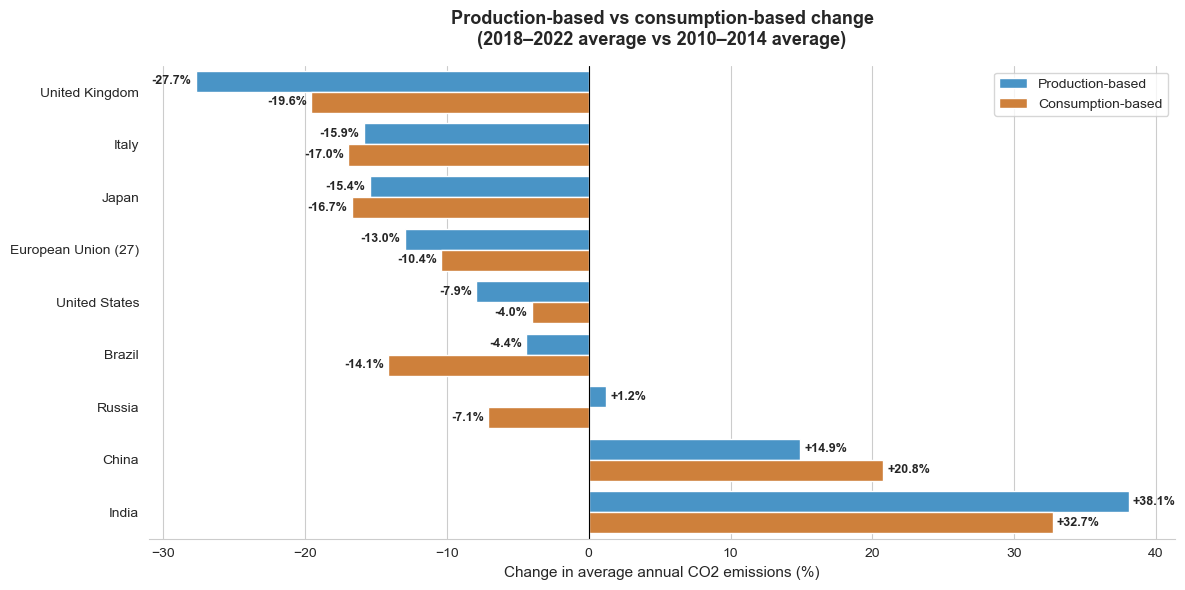

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))

# Reshape data for grouped bars
leakage_plot = leakage.melt(
    id_vars='country',
    value_vars=['prod_pct_change', 'cons_pct_change'],
    var_name='metric',
    value_name='pct_change'
)
leakage_plot['metric'] = leakage_plot['metric'].map({
    'prod_pct_change': 'Production-based',
    'cons_pct_change': 'Consumption-based'
})

# Sort countries by production-based change for consistent ordering
country_order = leakage.sort_values('prod_pct_change')['country'].tolist()

sns.barplot(
    data=leakage_plot,
    x='pct_change',
    y='country',
    hue='metric',
    order=country_order,
    palette={'Production-based': '#3498db', 'Consumption-based': '#e67e22'},
    edgecolor='white',
    ax=ax
)

ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Change in average annual CO2 emissions (%)', fontsize=11)
ax.set_ylabel('')
ax.set_title('Production-based vs consumption-based change\n'
             '(2018–2022 average vs 2010–2014 average)', 
             fontsize=13, fontweight='bold', pad=15)
ax.legend(title='', loc='upper right', frameon=True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

for container in ax.containers:
    ax.bar_label(container, fmt='%+.1f%%', padding=3, fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

**Key takeaway - leakage is real, but the story is uneven:**

- **The UK and US show clear leakage.** The UK's apparent 28% production-based reduction shrinks to 20% on consumption basis - roughly 8 percentage points "leaked" through imports. The US shows an even larger relative gap: half of its apparent 8% reduction disappears once trade is accounted for.

- **Italy and Japan show the *opposite* pattern.** Their consumption-based emissions fell *more* than production-based emissions. This means they 
  genuinely consumed less carbon-intensive goods - not just imported them from elsewhere. These are the most "honest" reductions in the sample.

- **Brazil and Russia have hidden cuts.** Their production stayed flat or slightly rose, but their *consumption* fell sharply. Both effectively became net exporters of embodied emissions during the period.

- **China's consumption grew faster than its production** (+21% vs +15%). The popular narrative that China's emissions are mostly "the West's outsourced manufacturing" is partly true but increasingly misleading: China's own domestic carbon-intensive consumption is rising rapidly as living standards rise.

- **India's story is largely domestic.** Consumption (+33%) tracks production (+38%) closely, suggesting most of India's emissions growth reflects internal development, not exports.

**Bottom line:** carbon leakage exists and modestly tarnishes the OECD's headline reductions - but it does *not* invalidate them. Even on consumption basis, the UK (-20%), Japan (-17%), Italy (-17%) and EU (-10%) have all reduced meaningfully. What's misleading is the assumption that *all* OECD reductions are leakage and *all* developing-country growth is imported. The geographic story is more heterogeneous than the simple narrative.